In [27]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
import seaborn as sns
from mlxtend.plotting import plot_decision_regions

import tensorflow
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.optimizers import Adam

In [28]:
X, y = make_moons(100, noise=0.25,random_state=2)

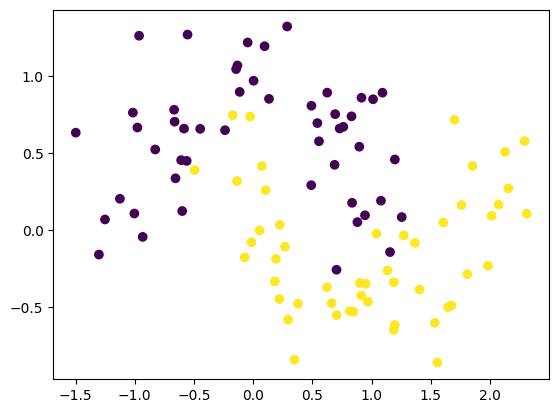

In [29]:
import matplotlib.pyplot as plt
plt.scatter(X[:,0], X[:,1], c=y)
plt.show()

In [30]:
model1 = Sequential()

model1.add(Dense(128,input_dim=2, activation="relu"))
model1.add(Dense(128, activation="relu"))
model1.add(Dense(1,activation='sigmoid'))

model1.summary()

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_9 (Dense)             (None, 128)               384       
                                                                 
 dense_10 (Dense)            (None, 128)               16512     
                                                                 
 dense_11 (Dense)            (None, 1)                 129       
                                                                 
Total params: 17025 (66.50 KB)
Trainable params: 17025 (66.50 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [31]:
adam = Adam(learning_rate=0.01)
model1.compile(loss='binary_crossentropy', optimizer=adam, metrics=['accuracy'])

history1 = model1.fit(X, y, epochs=2000, validation_split = 0.2,verbose=0)

9600/9600 [==============================] - 17s 2ms/step


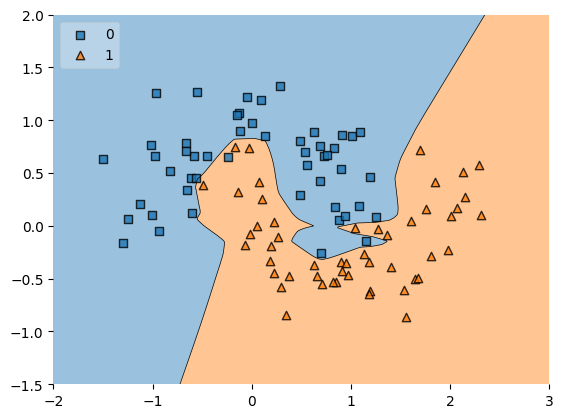

In [32]:
plot_decision_regions(X, y.astype('int'), clf=model1, legend=2)
plt.xlim(-2,3)
plt.ylim(-1.5,2)
plt.show()

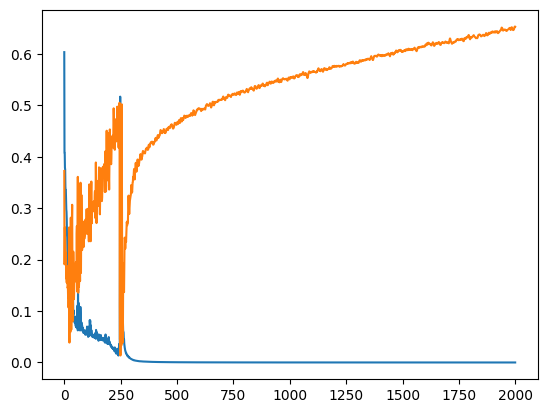

In [8]:
plt.plot(history1.history['loss'])
plt.plot(history1.history['val_loss'])

In [33]:
model2 = Sequential()

model2.add(Dense(128,input_dim=2, activation="relu",kernel_regularizer=tensorflow.keras.regularizers.l1(0.001)))
model2.add(Dense(128, activation="relu",kernel_regularizer=tensorflow.keras.regularizers.l1(0.001)))
model2.add(Dense(1,activation='sigmoid'))

model2.summary()

Model: "sequential_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_12 (Dense)            (None, 128)               384       
                                                                 
 dense_13 (Dense)            (None, 128)               16512     
                                                                 
 dense_14 (Dense)            (None, 1)                 129       
                                                                 
Total params: 17025 (66.50 KB)
Trainable params: 17025 (66.50 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [35]:
model2 = Sequential()

model2.add(Dense(128,input_dim=2, activation="relu",kernel_regularizer=tensorflow.keras.regularizers.l2(0.001)))
model2.add(Dense(128, activation="relu",kernel_regularizer=tensorflow.keras.regularizers.l2(0.001)))
model2.add(Dense(1,activation='sigmoid'))

model2.summary()

Model: "sequential_6"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_18 (Dense)            (None, 128)               384       
                                                                 
 dense_19 (Dense)            (None, 128)               16512     
                                                                 
 dense_20 (Dense)            (None, 1)                 129       
                                                                 
Total params: 17025 (66.50 KB)
Trainable params: 17025 (66.50 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [36]:
adam = Adam(learning_rate=0.01)
model2.compile(loss='binary_crossentropy', optimizer=adam, metrics=['accuracy'])

history2 = model2.fit(X, y, epochs=2000, validation_split = 0.2,verbose=0)

9600/9600 [==============================] - 18s 2ms/step


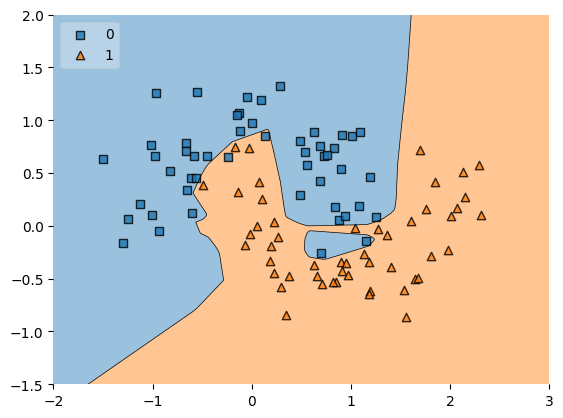

In [37]:
plot_decision_regions(X, y.astype('int'), clf=model2, legend=2)
plt.xlim(-2,3)
plt.ylim(-1.5,2)
plt.show()

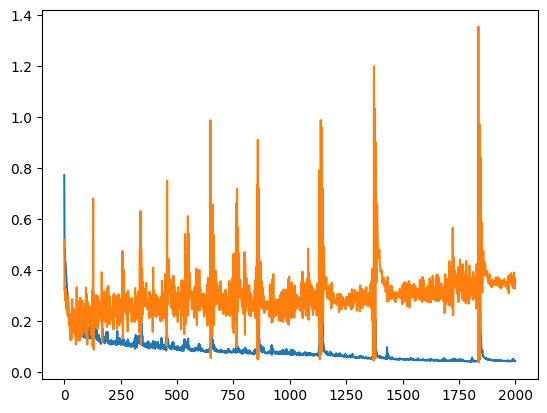

In [38]:
plt.plot(history2.history['loss'])
plt.plot(history2.history['val_loss'])

In [21]:
adam = Adam(learning_rate=0.01)
model2.compile(loss='binary_crossentropy', optimizer=adam, metrics=['accuracy'])

history2 = model2.fit(X, y, epochs=2000, validation_split = 0.2,verbose=0)

9600/9600 [==============================] - 27s 3ms/step


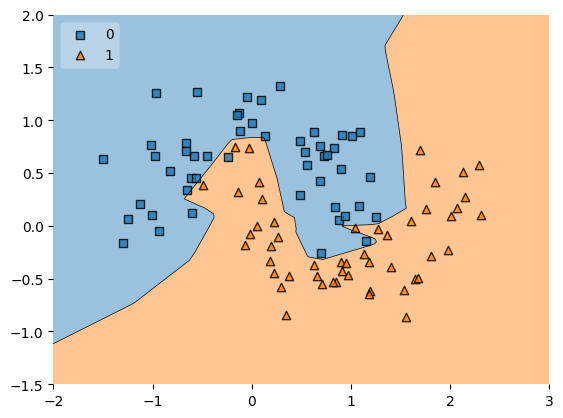

In [22]:
plot_decision_regions(X, y.astype('int'), clf=model2, legend=2)
plt.xlim(-2,3)
plt.ylim(-1.5,2)
plt.show()

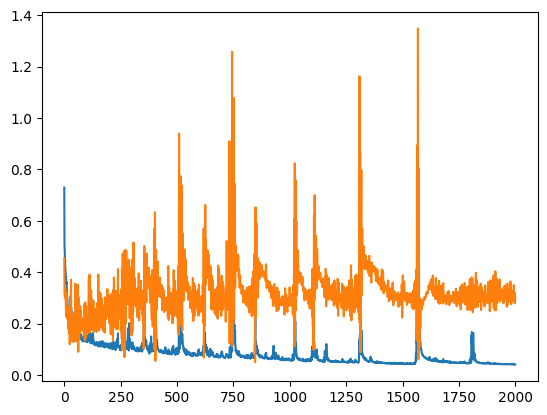

In [24]:
plt.plot(history2.history['loss'])
plt.plot(history2.history['val_loss'])

In [39]:
model1_weight_layer1 = model1.get_weights()[0].reshape(256)
model2_weight_layer1 = model2.get_weights()[0].reshape(256)

<Axes: >

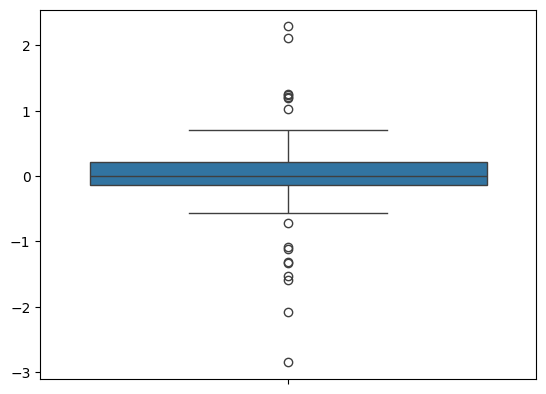

In [40]:
sns.boxplot(model1_weight_layer1)

<Axes: >

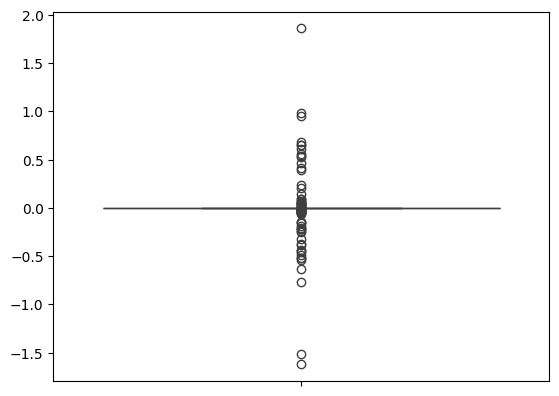

In [41]:
sns.boxplot(model2_weight_layer1)

In [42]:
model1_weight_layer1.max()

2.2898297

In [43]:
model1_weight_layer1.min()

-2.85272

In [44]:
model2_weight_layer1.max()

1.8603755

In [45]:
model2_weight_layer1.min()

-1.6219004

C:\Users\Kshama\AppData\Local\Temp\ipykernel_11548\2224180084.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(model1_weight_layer1)
C:\Users\Kshama\AppData\Local\Temp\ipykernel_11548\2224180084.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(model2_weight_layer1)


<Axes: ylabel='Density'>

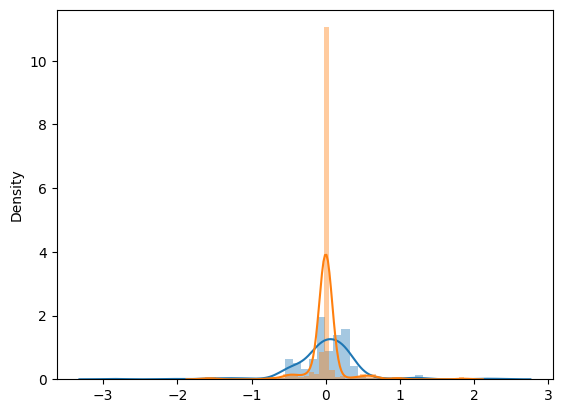

In [46]:
sns.distplot(model1_weight_layer1)
sns.distplot(model2_weight_layer1)

MemoryError: 

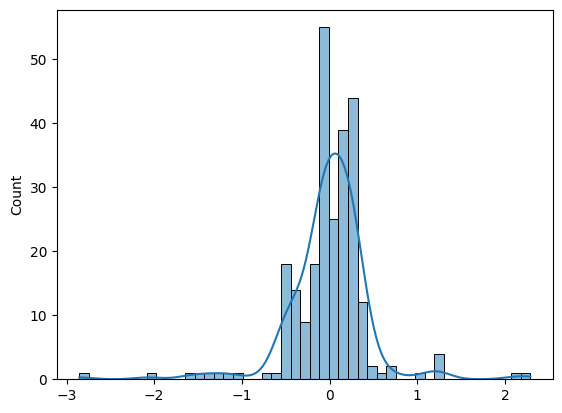

In [47]:
sns.histplot(model1_weight_layer1, kde=True)
sns.histplot(model2_weight_layer1, kde=True)

plt.show()

MemoryError: Unable to allocate 225. MiB for an array with shape (29466880,) and data type int64

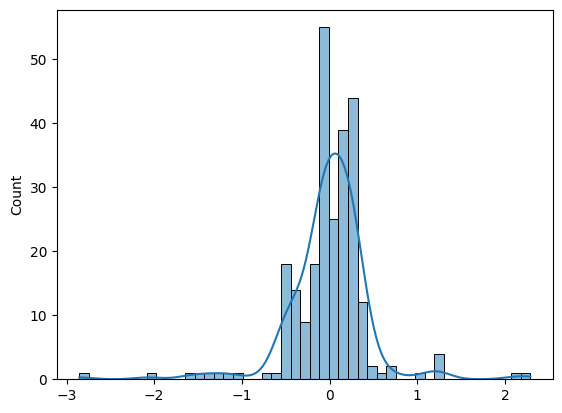

In [48]:
sns.histplot(model1_weight_layer1, kde=True, label="Model 1")
sns.histplot(model2_weight_layer1, kde=True, label="Model 2")

plt.legend()
plt.show()

In [49]:
model1.get_weights()[0].reshape(256)

array([ 0.39261106,  0.06919698, -0.4451268 ,  0.25278753,  0.01248249,
        0.18468286, -0.38631248, -0.4762811 , -0.51187277, -0.42968675,
        0.21909063, -0.22772214, -0.552962  , -0.4017153 ,  0.11794801,
        0.19441438,  0.18865603, -0.3113013 ,  0.2560567 , -0.04442076,
       -0.54231477,  0.2260576 , -0.26680648, -0.49681425, -0.48950082,
        0.19048782,  0.21368642,  0.27362713,  0.25341228, -0.20462796,
       -0.04417103, -0.49400818,  0.11220802, -0.09357035, -0.21746941,
        0.05287581,  0.2672127 ,  0.2852239 ,  0.01607485, -0.06601473,
       -0.529373  ,  0.05761882,  0.02954543,  0.04342049, -0.42001945,
        0.28724238,  0.28562582, -0.4561827 , -0.03973687,  0.17324622,
        0.23795487, -0.23167297,  0.17446078,  0.288573  ,  0.35633424,
       -0.22258765,  0.12253857, -0.02667131, -0.37224728, -0.2516119 ,
       -0.4143002 ,  0.21108226,  0.18975735, -0.4592904 ,  0.2670973 ,
       -0.35304716,  0.11876392, -0.03925647,  0.31147677, -0.08